<a href="https://colab.research.google.com/github/Maahi-w-tech/SDL-I/blob/main/Zomato_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
#from google.colab import drivedrive.mount('/content/drive',force_remount=True)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from matplotlib import rcParams
rcParams['figure.figsize'] = 11,8
import cufflinks as cf
from plotly.offline import download_plotlyjs,init_notebook_mode,plot,iplot
init_notebook_mode(connected=True)


In [7]:
df = pd.read_csv('zomato.csv', encoding='latin-1', engine='python')

In [8]:
df

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,NamlÛ± Gurme,208,ÛÁstanbul,"Kemankeô Karamustafa Paôa Mahallesi, RÛ±htÛ±...",Karakí_y,"Karakí_y, ÛÁstanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz AÛôacÛ±,208,ÛÁstanbul,"Koôuyolu Mahallesi, Muhittin íìstí_ndaÛô Cadd...",Koôuyolu,"Koôuyolu, ÛÁstanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,Aôôk Kahve,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


In [9]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [10]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [12]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [13]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


In [14]:
[features for features in df.columns if df[features].isnull().sum()>0]

['Cuisines']

<Axes: >

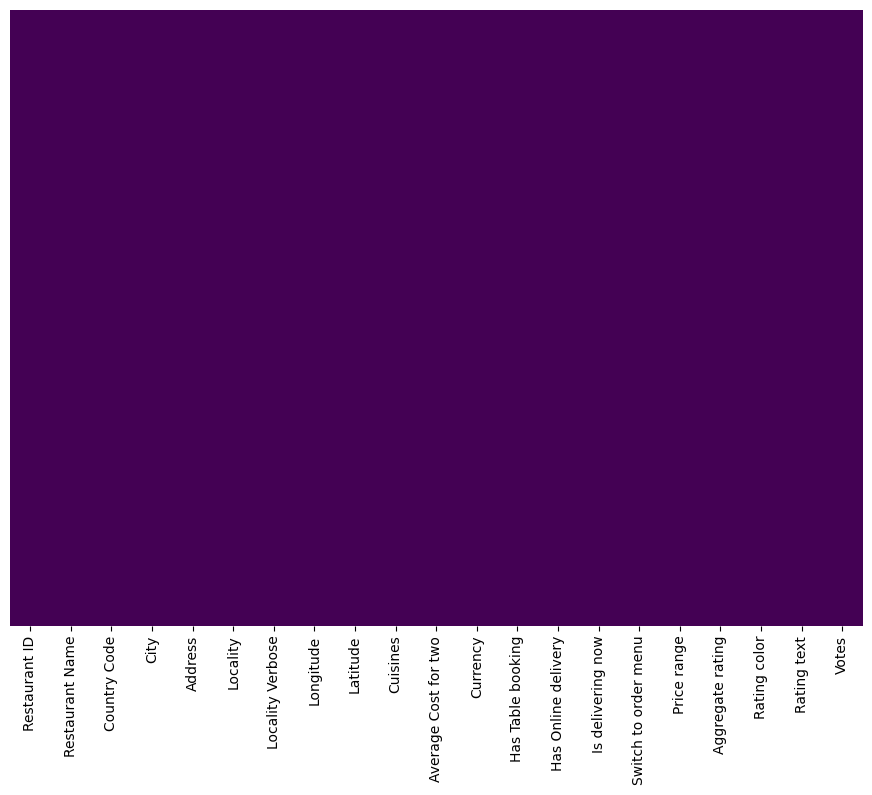

In [15]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [16]:
df_country= pd.read_excel('Country-Code.xlsx')
df_country.head()


,Country Code,Country
0,1,India
1,14,Australia
2,30,Brazil
3,37,Canada
4,94,Indonesia


In [17]:
final_df =pd.merge(df,df_country,how='left',on='Country Code')

In [18]:
final_df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Phillipines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,Phillipines
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,No,4,4.9,Dark Green,Excellent,365,Phillipines
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Phillipines


In [19]:
country_names=final_df.Country.value_counts().index
country_names

Index(['India', 'United States', 'United Kingdom', 'Brazil', 'South Africa',
       'UAE', 'New Zealand', 'Turkey', 'Australia', 'Phillipines', 'Indonesia',
       'Qatar', 'Singapore', 'Sri Lanka', 'Canada'],
      dtype='object', name='Country')

In [20]:
country_val = final_df.Country.value_counts().values
country_val

array([8652,  434,   80,   60,   60,   60,   40,   34,   24,   22,   21,
         20,   20,   20,    4])

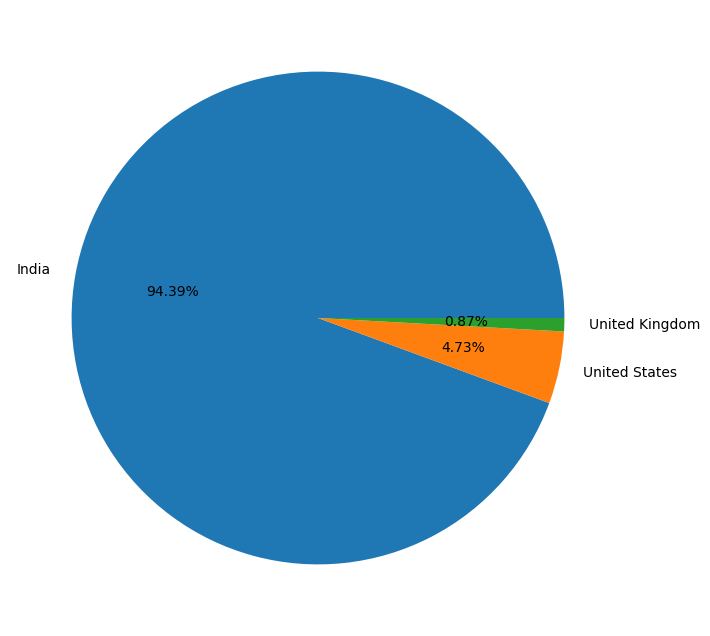

<Figure size 1100x800 with 0 Axes>

In [21]:
#Pie Chart for top 3 Countries that use Zomato
plt.pie(country_val[:3], labels=country_names[:3],autopct='%1.2f%%')
plt.show()
plt.savefig('pie.png')

#📊Observations:
* India dominates Zomato usage, accounting for 94.39% of the total
 restaurants in the dataset.
* This clearly indicates that Zomato’s primary market and strongest operational presence is in India.

* The United States (4.73%) contributes a very small share compared to India, suggesting that Zomato has limited penetration or selective coverage in the US market.

* The United Kingdom (0.87%) has the lowest representation, indicating minimal adoption relative to India and the US.

In [22]:
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='object')

In [23]:
ratings =final_df.groupby(['Aggregate rating', 'Rating color','Rating text']).size().reset_index().rename(columns={0:'Rating Count'})

In [24]:
ratings

,Aggregate rating,Rating color,Rating text,Rating Count
0,0.0,White,Not rated,2148
1,1.8,Red,Poor,1
2,1.9,Red,Poor,2
3,2.0,Red,Poor,7
4,2.1,Red,Poor,15
5,2.2,Red,Poor,27
6,2.3,Red,Poor,47
7,2.4,Red,Poor,87
8,2.5,Orange,Average,110
9,2.6,Orange,Average,191




#📊 Observation: Aggregate Rating Distribution

* A large number of restaurants are unrated (0.0), indicating new or No listings.

* Most restaurants fall in the Average (2.5–3.4) rating range, showing moderate food quality overall.

* Good to Very Good (3.5–4.4) rated restaurants are well represented, offering reliable dining options.

* Excellent-rated (4.5+) restaurants are relatively rare, making them stand out as premium choices.

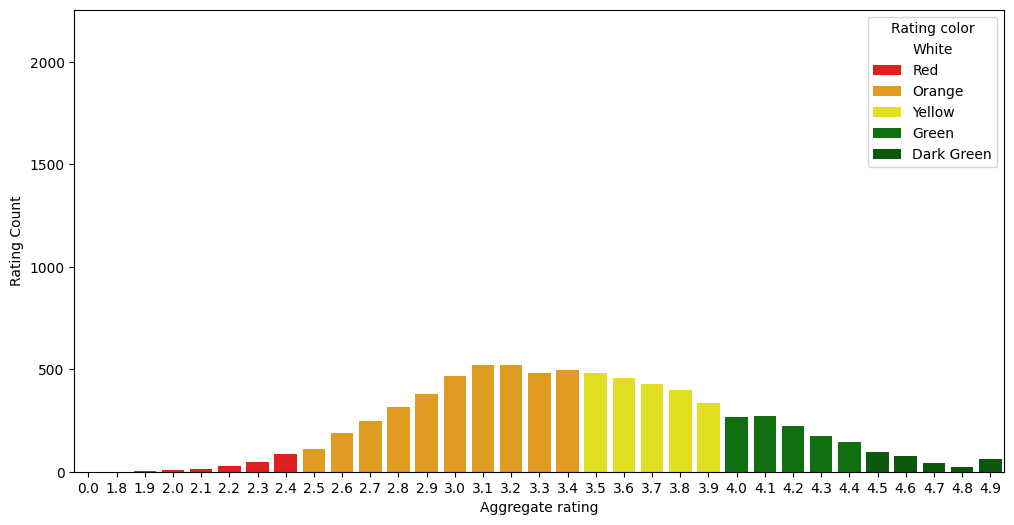

In [25]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12,6)
sns.barplot(x='Aggregate rating',y='Rating Count',data=ratings,hue='Rating color',palette=['white','red','orange','yellow','green','darkgreen'])


plt.savefig('Rating Count')

#📊 Observations: Rating Count vs Aggregate Rating

* A large spike at rating 0 indicates many restaurants are unrated.

* Most rated restaurants are clustered between 2.5 and 4.0, showing average to good quality.

* Higher ratings (4.5+) have fewer restaurants, making them relatively rare.

<Axes: xlabel='Rating color', ylabel='count'>

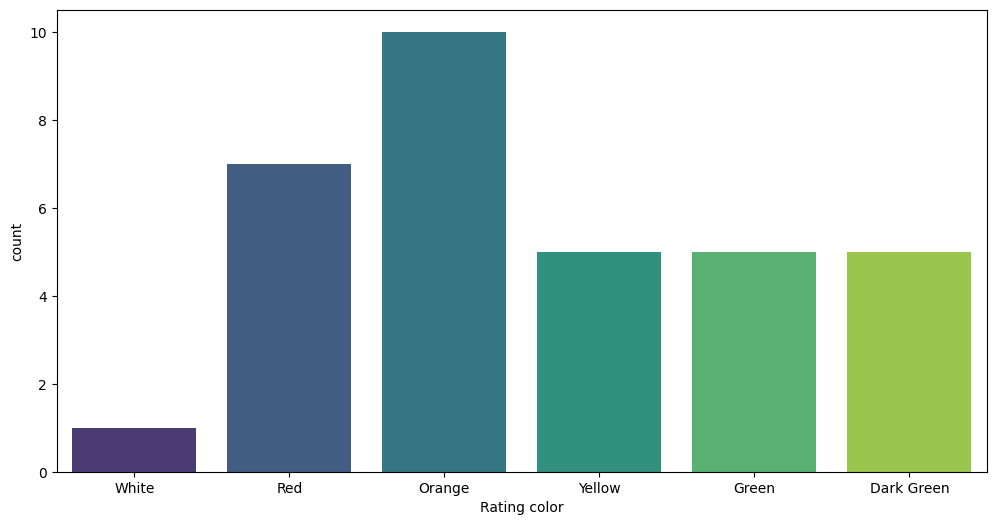

In [26]:
# Count Plot
sns.countplot(x="Rating color",data= ratings ,palette="viridis")

In [27]:
### The countries which have given zero ratings
country_0 = final_df[final_df['Rating color']=='White'].groupby('Country').size().reset_index().rename(columns={0:'White Rating Count'})
country_0

,Country,White Rating Count
0,Brazil,5
1,India,2139
2,United Kingdom,1
3,United States,3


<Axes: xlabel='Country', ylabel='White Rating Count'>

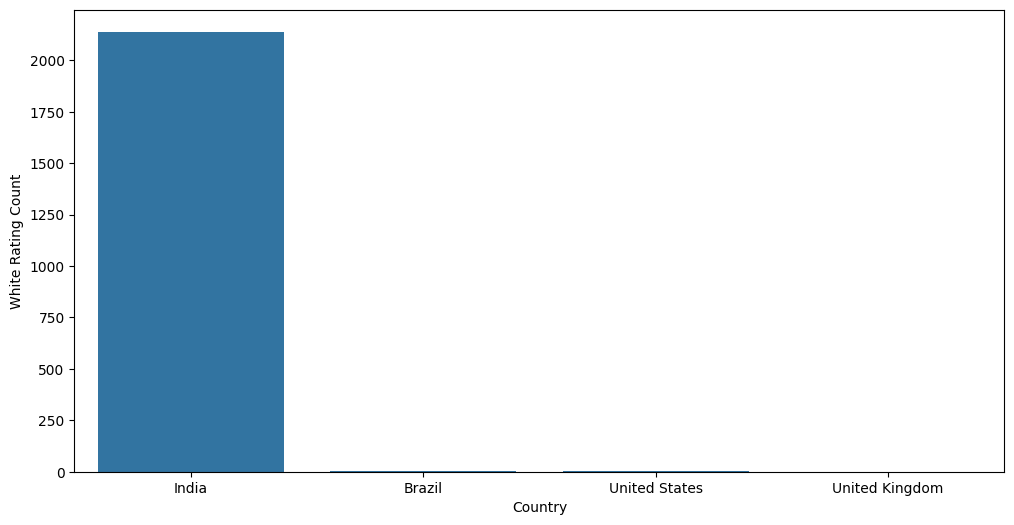

In [28]:
white_count=country_0.sort_values(by='White Rating Count',ascending=False)
sns.barplot(x='Country',y='White Rating Count',data=white_count)

# 📊Observations: White Rating Counts
India has an overwhelmingly high number of unrated (White rating) restaurants compared to other countries, indicating a large presence of newly listed or low-review restaurants. Brazil, the United States, and the United Kingdom contribute only a negligible share of unrated listings.

In [29]:
final_df[['Country','Currency']].groupby(['Country','Currency']).size().reset_index()

,Country,Currency,0
0,Australia,Dollar($),24
1,Brazil,Brazilian Real(R$),60
2,Canada,Dollar($),4
3,India,Indian Rupees(Rs.),8652
4,Indonesia,Indonesian Rupiah(IDR),21
5,New Zealand,NewZealand($),40
6,Phillipines,Botswana Pula(P),22
7,Qatar,Qatari Rial(QR),20
8,Singapore,Dollar($),20
9,South Africa,Rand(R),60


In [30]:
## countries which have online delivery
final_df[['Has Online delivery','Country']].groupby(['Has Online delivery','Country']).size().reset_index()

,Has Online delivery,Country,0
0,No,Australia,24
1,No,Brazil,60
2,No,Canada,4
3,No,India,6229
4,No,Indonesia,21
5,No,New Zealand,40
6,No,Phillipines,22
7,No,Qatar,20
8,No,Singapore,20
9,No,South Africa,60


##📊Observations: Online Deliveries Available
Only India and UK have Online deliveries available in their country.

In [40]:
city_name= final_df.City.value_counts().index

In [32]:
city_val =final_df.City.value_counts().values

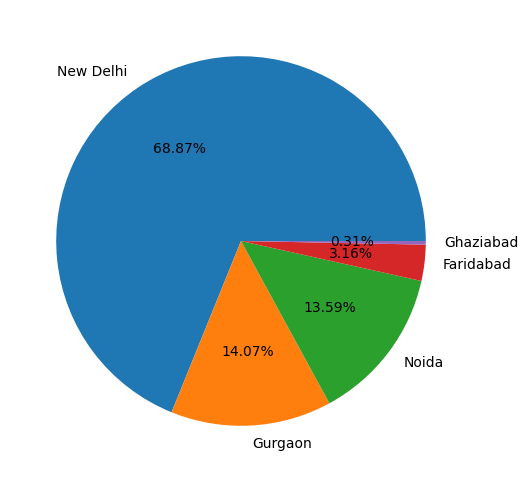

<Figure size 1200x600 with 0 Axes>

In [33]:
plt.pie(city_val[:5], labels=city_name[:5],autopct='%1.2f%%')
plt.show()
plt.savefig('pie2.png')

## 📊Observations:
The distribution of restaurants is highly concentrated in New Delhi, which alone accounts for nearly 69% of the listings. Gurgaon (14%) and Noida (13.6%) also show strong presence, highlighting them as major food hubs in the NCR region. In contrast, Faridabad and Ghaziabad contribute a very small share, indicating limited Zomato coverage or lower restaurant density in these areas.

In [36]:
### The countries which have given 4> ratings
country_5 = final_df[final_df['Rating color']=='Dark Green'].groupby('Country').size().reset_index().rename(columns={0:'Dark Green Rating Count'})
country_5

,Country,Dark Green Rating Count
0,Australia,1
1,Brazil,16
2,India,116
3,Indonesia,7
4,New Zealand,12
5,Phillipines,12
6,Qatar,4
7,South Africa,12
8,Sri Lanka,2
9,Turkey,10


<Axes: xlabel='Country', ylabel='Dark Green Rating Count'>

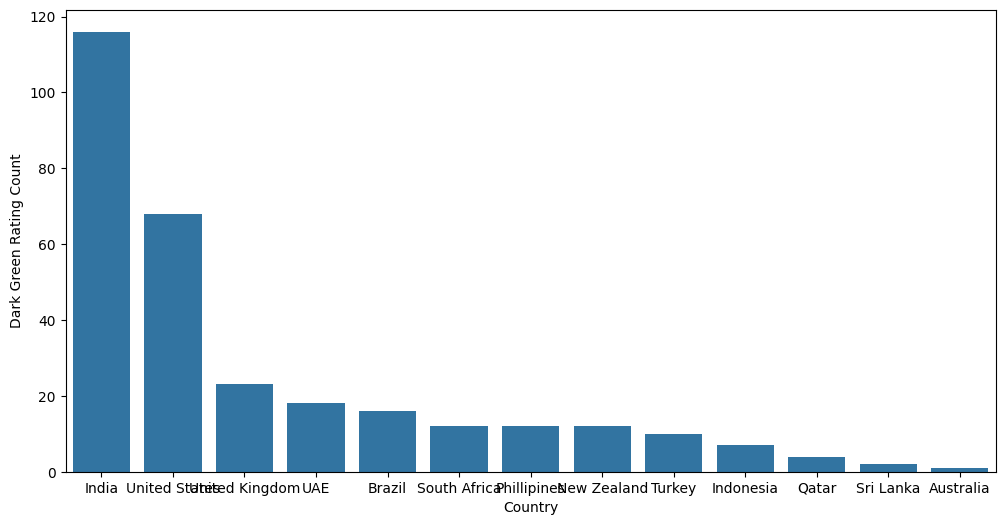

In [50]:
DGreen_count=country_5.sort_values(by='Dark Green Rating Count',ascending=False)
sns.barplot(x='Country',y='Dark Green Rating Count',data=DGreen_count)


## 📊Obseravtion: Highly Rated Restraunts
* India has the highest number of highly rated (dark green) restaurants, reflecting both strong platform presence and a large restaurant base.

* The United States ranks second, but with a significantly lower count compared to India, indicating a sharp drop after the top country.

* Other countries such as the United Kingdom, UAE, and Brazil contribute a much smaller share, showing limited representation of top-rated restaurants.

* Overall, highly rated restaurants are heavily concentrated in a few countries, suggesting that data-driven recommendations will be most impactful in regions with higher Zomato penetration.

In [51]:
india_darkgreen_restaurants = final_df[
    (final_df['Country'] == 'India') &
    (final_df['Rating color'] == 'Dark Green')
]

india_darkgreen_restaurants.head()


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
637,3400346,Sheroes Hangout,1,Agra,"Opposite The Gateway Hotel, Fatehabad Road, Ta...",Tajganj,"Tajganj, Agra",78.040165,27.161850,"Cafe, North Indian, Chinese",...,No,No,No,No,1,4.9,Dark Green,Excellent,77,India
646,18396250,Huber & Holly,1,Ahmedabad,"7 B, Circle B, Opposite Rajpath Club, Sarkhej...",Bodakdev,"Bodakdev, Ahmedabad",72.512395,23.038311,"Ice Cream, Desserts, Continental",...,No,Yes,No,No,1,4.5,Dark Green,Excellent,217,India
653,18385201,Cryo Lab,1,Ahmedabad,"Ground Floor, Arjun Avenue, Opposite Samarthes...",Ellis Bridge,"Ellis Bridge, Ahmedabad",72.559984,23.028748,"Desserts, Ice Cream",...,No,No,No,No,2,4.6,Dark Green,Excellent,166,India
660,113325,Nini's Kitchen,1,Ahmedabad,"12, First Floor, Camps Corner 2, Opposite Prah...",Prahlad Nagar,"Prahlad Nagar, Ahmedabad",72.507265,23.011772,"North Indian, Continental, Beverages, Italian,...",...,No,Yes,No,No,3,4.5,Dark Green,Excellent,1138,India
727,58268,The Fatty Bao - Asian Gastro Bar,1,Bangalore,"610, 3rd Floor, 12th Main, Off 80 Feet Road, I...",Indiranagar,"Indiranagar, Bangalore",77.645396,12.970221,Asian,...,Yes,Yes,No,No,4,4.7,Dark Green,Excellent,2369,India


<Figure size 1400x600 with 0 Axes>

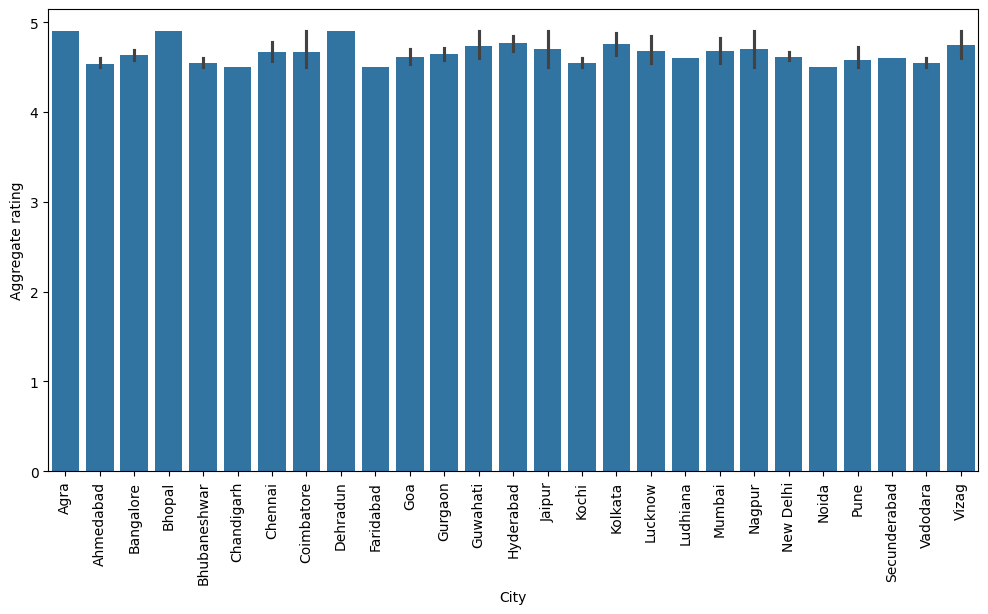

<Figure size 1400x600 with 0 Axes>

In [53]:
sns.barplot(x='City',y='Aggregate rating',data=india_darkgreen_restaurants)
plt.xticks(rotation=90)
plt.figure(figsize=(14,6))


## 📊 Observations: Average Rating of Highly Rated Restaurants Across Indian Cities

* The average ratings across cities are consistently high, mostly ranging between 4.5 and 4.9, indicating uniformly strong food quality among highly rated restaurants.

* Cities such as Agra, Bhopal, Dehradun, Hyderabad, and Vizag show some of the highest average ratings, reflecting excellent dining experiences.

* Metro and non-metro cities display comparable rating levels, suggesting that high-quality food is not limited to major metropolitan areas.

* The relatively small variation in average ratings indicates consistent quality standards across cities.